IMPORT LIBRARY


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score

EDA AND DATA IMPORT

In [69]:
data = pd.read_csv("home_dataset.csv")

In [70]:
data.head(5)

,HouseSize,HousePrice
0,793,1300000
1,2477,3700000
2,1263,1480000
3,1291,2380000
4,603,955000


In [71]:
data.describe()

,HouseSize,HousePrice
count,59.000000,5.900000e+01
mean,1254.762712,1.875949e+06
std,519.147422,7.883950e+05
min,389.000000,1.000000e+00
25%,793.000000,1.285000e+06
50%,1230.000000,1.870000e+06
75%,1619.500000,2.435000e+06
max,3058.000000,3.700000e+06


In [72]:
data.columns

Index(['HouseSize', 'HousePrice'], dtype='object')

In [73]:
data.isna().sum()

,0
HouseSize,0
HousePrice,0


In [74]:
house_size = data ['HouseSize'].values
house_price = data ['HousePrice'].values

In [75]:
house_size

array([ 793, 2477, 1263, 1291,  603, 1655, 1071, 1877, 1610, 3058, 1609,
       1630, 1211, 1219, 1700, 1629,  740,  740, 1637, 1637, 1291, 1211,
        400,  800,  700, 1711,  847, 1230, 1291, 2300,  886, 1700,  389,
        793,  978,  582,  793, 1327,  791,  793, 1630,  740, 1244, 1183,
       1327, 1183, 1643, 2500, 1085,  740, 1291, 1291,  740, 1230, 1219,
       1275,  793, 1259, 1395])

In [76]:
house_price

array([1300000, 3700000, 1480000, 2380000,  955000, 2130000, 1300000,
       2700000, 2650000, 2850000, 2250000, 2950000, 1900000, 1820000,
       2100000, 2480000, 1270000, 1260000, 2520000, 3450000, 2430000,
       2250000,       1,  925000,  950000, 2630000,  975000, 1570000,
       2010000, 3630000, 1120000, 2020000,  695974, 1330000, 1460000,
        685000, 1340000, 2440000,  925000, 1400000, 2980000, 1200000,
       1650000, 1880000, 2440000, 1880000, 2790000, 3470000, 1160000,
       1230000, 2180000, 2060000, 1270000, 1660000, 1870000, 1800000,
       1330000, 1650000, 1950000])

MODEL USING SCIPY STATS


In [77]:
slope1, intercept1, r_value1, p_value1, std_err1 = stats.linregress(house_price, house_size)

In [78]:
slope1

np.float64(0.0005821723214763111)

In [79]:
intercept1

np.float64(162.63728544048217)

In [80]:
r_value1

np.float64(0.8841068032865116)

In [81]:
std_err1

np.float64(4.075595962860841e-05)

In [82]:
p_value1

np.float64(1.7366743921821375e-20)

In [83]:
y_pred = intercept1 + slope1 * house_size

In [84]:
print(f"y_pred = {intercept1} + {slope1} * x")

y_pred = 162.63728544048217 + 0.0005821723214763111 * x


##GOODNESS OF FIT

In [85]:
y = house_price

In [86]:
# hitung MSE
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

#hitung RMSE
rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2= r2_score(y, y_pred)
print("r2: ", r2)

MSE: 4129602009107.759
RMSE: 2032142.2216734139
r2:  -5.758408756067953


USING SCIKIT LEARN


In [87]:
from sklearn.linear_model import LinearRegression

#definisikan dulu X dan y nya
X = data[['HouseSize']].values # .values itu bikin datanya jadi tipe array
y = data['HousePrice'].values

# membuat model regresi linear
model = LinearRegression() # didefinisikan dulu modelny adalah regresi, dan disimpan di variabel model
# latih model dengan X dan y yang sudah didefinisikan
model.fit(X, y)

# hasil
slope = model.coef_[0]
intercept = model.intercept_
y_pred1 = model.predict(X)

print("Slope:", slope)
print("Intercept:", intercept)


Slope: 1342.6348364266926
Intercept: 191260.60041517834


In [88]:
model.score(X, y_pred1)

1.0

Visualize the correlation


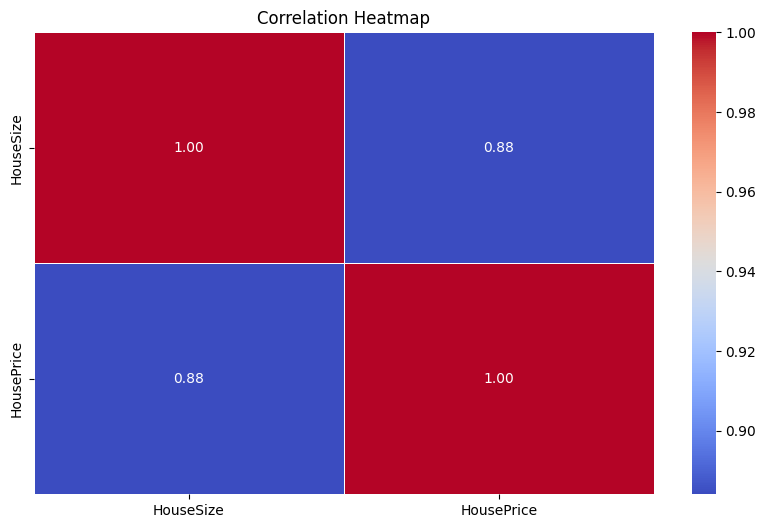

In [89]:
# melihat korelasi antar variabel dengan heatmap
import seaborn as sns

corr = data.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

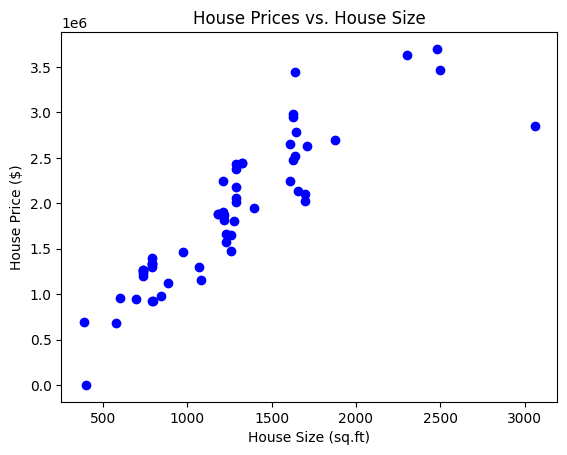

In [90]:
# Visualize the data
plt.scatter(house_size, house_price, marker ='o', color ='blue')
plt.title('House Prices vs. House Size')
plt.xlabel('House Size (sq.ft)')
plt.ylabel('House Price ($)')
plt.show()

Train, Test, Split

In [91]:
# Split the data into training and testing sets - TRAIN, TEST, SPLIT
x_train, x_test, y_train, y_test = train_test_split(house_size, house_price, test_size=0.2, random_state=42)

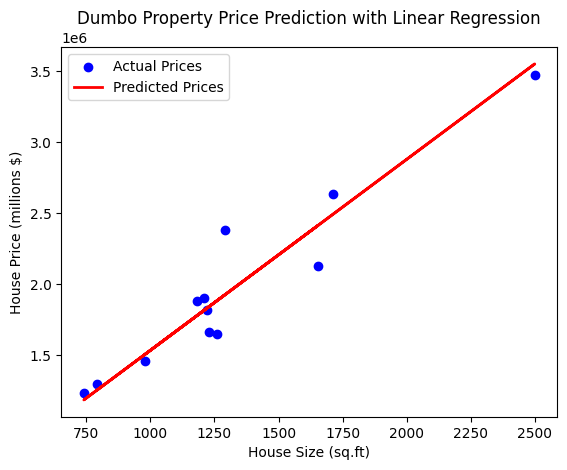

In [92]:
# Predict prices for the test set
predictions = model.predict(x_test.reshape(-1, 1))

# Visualize the predictions
plt.scatter(x_test, y_test, marker='o', color='blue', label='Actual Prices')
plt.plot(x_test, predictions, color='red', linewidth=2, label='Predicted Prices')
plt.title('Dumbo Property Price Prediction with Linear Regression')
plt.xlabel('House Size (sq.ft)')
plt.ylabel('House Price (millions $)')
plt.legend()
plt.show()

OLS Result

In [93]:
import statsmodels.api as sm
X = X
y = y_pred

X = sm.add_constant(X)

# membuat model
model1 = sm.OLS(y, X).fit()

print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.198e+27
Date:                Sat, 22 Nov 2025   Prob (F-statistic):               0.00
Time:                        04:19:31   Log-Likelihood:                 1707.5
No. Observations:                  59   AIC:                            -3411.
Df Residuals:                      57   BIC:                            -3407.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        162.6373   2.28e-14   7.13e+15      0.0

Residual Analysis

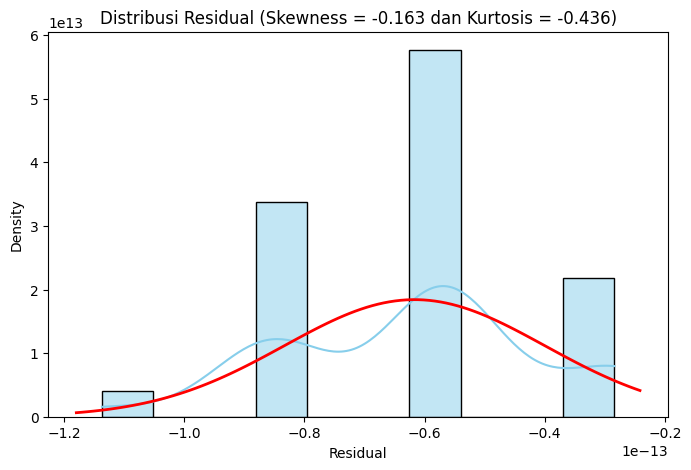

In [94]:
import scipy.stats as stats

residuals = model1.resid

# Histogram dengan kurva normal
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=10, kde=True, color="skyblue", stat="density")

# Kurva normal pembanding
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, residuals.mean(), residuals.std())
plt.plot(x, p, 'r', linewidth=2)

plt.title("Distribusi Residual " + "(Skewness = {:.3f}".format(stats.skew(residuals)) + " dan Kurtosis = {:.3f})".format(stats.kurtosis(residuals)))
plt.xlabel("Residual")
plt.ylabel("Density")
plt.show()